In [1]:
import torch
import numpy as np
import math
import matplotlib.pyplot as plt
from cryo_sbi.utils.infer_populations import generate_population_weights

Install with: conda install conda-forge::numpyro


In [2]:
def rmsd(P, Q):
    """
    Compute RMSD between two models without alignment.
    """
    return np.sqrt(np.mean(np.sum((P - Q)**2, axis=1)))


def plot_weights_comparison(x_opt, w_actual, ax):
    """
    Plot comparison between optimized and actual weights with RMSE.
    """

    # Convert to numpy if needed
    if torch.is_tensor(x_opt):
        x_opt = x_opt.detach().cpu().numpy()
    if torch.is_tensor(w_actual):
        w_actual = w_actual.detach().cpu().numpy()

    # Calculate RMSE
    rmse = np.sqrt(np.mean((x_opt - w_actual) ** 2))

    n_mod = len(x_opt)
    model_indexes = np.arange(1, n_mod + 1)
    bar_width = 0.35
    x_pos = np.arange(n_mod)

    # Plot bars
    ax.bar(
        x_pos - bar_width / 2,
        x_opt,
        bar_width,
        label="CryoBear weights",
        color="#3498db",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    ax.bar(
        x_pos + bar_width / 2,
        w_actual,
        bar_width,
        label="True weights",
        color="#2ecc71",
        alpha=0.8,
        edgecolor="black",
        linewidth=1.2,
    )

    # Styling
    ax.set_xlabel("Model Index", fontsize=11, weight="bold")
    ax.set_ylabel("Weight", fontsize=11, weight="bold")
    ax.set_title(f"RMSE = {rmse:.6f}", fontsize=8, weight="bold")
    ax.set_xticks(x_pos)
    ax.set_xticklabels(model_indexes)
    ax.set_xlim(-0.5, n_mod - 0.5)
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    return rmse



def compute_rmse_heatmaps(
    rmse_list,
    pop_fraction_list,
    rmsds_to_closed,
    models,
    population_steps,
):
    """
    Compute heatmaps for multiple RMSE/pop_fraction inputs,
    using delta population on the y-axis.

    Parameters
    ----------
    rmse_list : list of np.ndarray
        Each element is an array of RMSE values for one run.
    pop_fraction_list : list of np.ndarray
        Each element is an array of population fractions (0-1) matching rmse_list.
    rmsds_to_closed : np.ndarray
        RMSD values for each model/state.
    models : list
        Used to determine n_states.
    population_steps : int
        Number of mixture steps (default: 11)

    Returns
    -------
    heatmaps : list of 2D np.ndarray
        One heatmap per RMSE input.
    x_levels : np.ndarray
        Sorted unique RMSD values (columns of heatmap).
    y_levels_delta : np.ndarray
        Sorted unique delta populations (%).
    """

    # Precompute state indices (same for all runs)
    w, _, state_pairs = generate_population_weights(
        n_states=len(models),
        population_steps=population_steps,
    )
    state_indices = np.array([pair[1] for pair in state_pairs])

    # Precompute x-values (same for all runs)
    x_values = rmsds_to_closed[state_indices]
    x_levels = np.unique(x_values)

    heatmaps = []

    for rmse_values, pop_fractions in zip(rmse_list, pop_fraction_list):

        # Convert fraction to delta population: delta = state0 - other
        #delta_values = (2 * pop_fractions - 1) * 100
        delta_values = (pop_fractions) * 100
        y_levels_delta = np.unique(delta_values)

        heatmap = np.zeros((len(y_levels_delta), len(x_levels)))

        for i, y in enumerate(y_levels_delta):
            for j, x in enumerate(x_levels):
                idx = np.where((delta_values == y) & (x_values == x))[0]
                if len(idx) > 0:
                    heatmap[i, j] = rmse_values[idx[0]]

        heatmaps.append(heatmap)

    return heatmaps, x_levels, y_levels_delta


def plot_heatmap(
    heatmap,
    x_levels,
    y_levels,
    title,
    rmse_min=None,
    rmse_max=None,
    show_values=True,
    highlight_pure_state=True
):
    """
    Improved heatmap for RMSE vs delta population.

    Parameters
    ----------
    heatmap : 2D np.ndarray
        Heatmap values (rows = delta population, columns = mixture states)
    x_levels : np.ndarray
        Columns (e.g., RMSD to closed state)
    y_levels : np.ndarray
        Rows (delta population, %)
    title : str
        Plot title
    rmse_min, rmse_max : float, optional
        Min/max for color scale (consistent across multiple heatmaps)
    show_values : bool
        Whether to annotate RMSE values
    highlight_pure_state : bool
        Whether to visually highlight the top row (pure state)
    """

    #plt.figure(figsize=(12, 7))

    # Set color limits
    if rmse_min is None:
        rmse_min = np.nanmin(heatmap)
    if rmse_max is None:
        rmse_max = np.nanmax(heatmap)

    # Plot heatmap
    im = plt.imshow(
        heatmap,
        origin='lower',
        aspect='auto',
        cmap='viridis',
        vmin=rmse_min,
        vmax=rmse_max
    )

    # Compute cell centers for annotation
    x_centers = np.arange(heatmap.shape[1])
    y_centers = np.arange(heatmap.shape[0])

    if show_values:
        for i in range(heatmap.shape[0]):
            for j in range(heatmap.shape[1]):
                value = heatmap[i, j]
                # Only annotate if value > 0
                if value > 0:
                    plt.text(
                        x_centers[j],
                        y_centers[i],
                        f"{value:.4f}",  # show small values clearly
                        ha='center',
                        va='center',
                        fontsize=13,
                        fontweight='bold',
                        color='white' 
                    )

    # Set ticks
    plt.xticks(ticks=np.arange(len(x_levels)), labels=[f"0↔{i+1}" for i in range(len(x_levels))], fontsize=13)
    plt.yticks(ticks=np.arange(len(y_levels)), labels=[f"{y:.0f}" for y in y_levels], fontsize=13)

    # Labels and title
    plt.xlabel("RMSD w.r.t closed state (Å)", fontsize=15, fontweight='bold')
    plt.ylabel("Delta Population (%)", fontsize=15, fontweight='bold')
    plt.title(title, fontsize=16, fontweight='bold')

    # Colorbar
    cbar = plt.colorbar(im, fraction=0.046, pad=0.04)
    cbar.set_label("RMSE", fontsize=15, fontweight='bold')
    cbar.ax.tick_params(labelsize=15)

    plt.tight_layout()
    #plt.show()




In [3]:
models = torch.load('../../hsp90_models-small.pt')

rmse_values_10k_1 = np.load('inference1/10k_rmse.npy')
w_actual_10k_1 = np.load('inference1/10k_a_w.npy')
w_opt_10k_1 = np.load('inference1/10k_opt_w.npy')
pop_fractions_10k_1 = np.load('inference1/10k_pop.npy')

rmse_values_10k_2 = np.load('inference2/10k_rmse.npy')
w_actual_10k_2 = np.load('inference2/10k_a_w.npy')
w_opt_10k_2 = np.load('inference2/10k_opt_w.npy')
pop_fractions_10k_2 = np.load('inference2/10k_pop.npy')

rmse_values_10k_3 = np.load('inference3/10k_rmse.npy')
w_actual_10k_3 = np.load('inference3/10k_a_w.npy')
w_opt_10k_3 = np.load('inference3/10k_opt_w.npy')
pop_fractions_10k_3 = np.load('inference3/10k_pop.npy')


rmse_values_100k_1 = np.load('inference1/100k_rmse.npy')
w_actual_100k_1 = np.load('inference1/100k_a_w.npy')
w_opt_100k_1 = np.load('inference1/100k_opt_w.npy')
pop_fractions_100k_1 = np.load('inference1/100k_pop.npy')

rmse_values_100k_2 = np.load('inference2/100k_rmse.npy')
w_actual_100k_2 = np.load('inference2/100k_a_w.npy')
w_opt_100k_2 = np.load('inference2/100k_opt_w.npy')
pop_fractions_100k_2 = np.load('inference2/100k_pop.npy')

rmse_values_100k_3 = np.load('inference3/100k_rmse.npy')
w_actual_100k_3 = np.load('inference3/100k_a_w.npy')
w_opt_100k_3 = np.load('inference3/100k_opt_w.npy')
pop_fractions_100k_3 = np.load('inference3/100k_pop.npy')

rmse_values_1M_1 = np.load('inference1/1M_rmse.npy')
w_actual_1M_1 = np.load('inference1/1M_a_w.npy')
w_opt_1M_1 = np.load('inference1/1M_opt_w.npy')
pop_fractions_1M_1 = np.load('inference1/1M_pop.npy')

rmse_values_1M_2 = np.load('inference2/1M_rmse.npy')
w_actual_1M_2 = np.load('inference2/1M_a_w.npy')
w_opt_1M_2 = np.load('inference2/1M_opt_w.npy')
pop_fractions_1M_2 = np.load('inference2/1M_pop.npy')

rmse_values_1M_3 = np.load('inference3/1M_rmse.npy')
w_actual_1M_3 = np.load('inference3/1M_a_w.npy')
w_opt_1M_3 = np.load('inference3/1M_opt_w.npy')
pop_fractions_1M_3 = np.load('inference3/1M_pop.npy')

In [4]:
rmse_random_10k = np.load('inference1_random/10k_rmse.npy')
rmse_random_100k = np.load('inference1_random/100k_rmse.npy')
rmse_random_1M = np.load('inference1_random/1M_rmse.npy')

In [5]:
rmse_values_10k = np.mean([rmse_values_10k_1, rmse_values_10k_2, rmse_values_10k_3], axis = 0)
rmse_values_100k = np.mean([rmse_values_100k_1, rmse_values_100k_2, rmse_values_100k_3], axis = 0)
rmse_values_1M = np.mean([rmse_values_1M_1, rmse_values_1M_2, rmse_values_1M_3], axis = 0)

In [5]:
# Here we simulate 20 models, 1207 atoms each
n_models = models.shape[0]
n_atoms = models.shape[2]
# Transpose to shape (n_models, n_atoms, 3) for RMSD calculation
coords = models.cpu().numpy().transpose(0, 2, 1)

# RMSD of each model to the closed state (model 0)
rmsds_to_closed = np.array([rmsd(coords[0], coords[i]) for i in range(n_models)])

In [6]:
heatmaps, x_levels, y_levels = compute_rmse_heatmaps(
    rmse_list=[rmse_values_10k_1,rmse_values_10k_2, rmse_values_10k_3],
    pop_fraction_list=[pop_fractions_10k_1,pop_fractions_10k_2, pop_fractions_10k_3],
    rmsds_to_closed=rmsds_to_closed,
    models=models,
    population_steps=5
)
title_labels = ["10k images 1","10k images 2","10k images 3"]

In [7]:
global_rmse_min = np.nanmin([np.nanmin(hm) for hm in heatmaps])
global_rmse_max = np.nanmax([np.nanmax(hm) for hm in heatmaps])


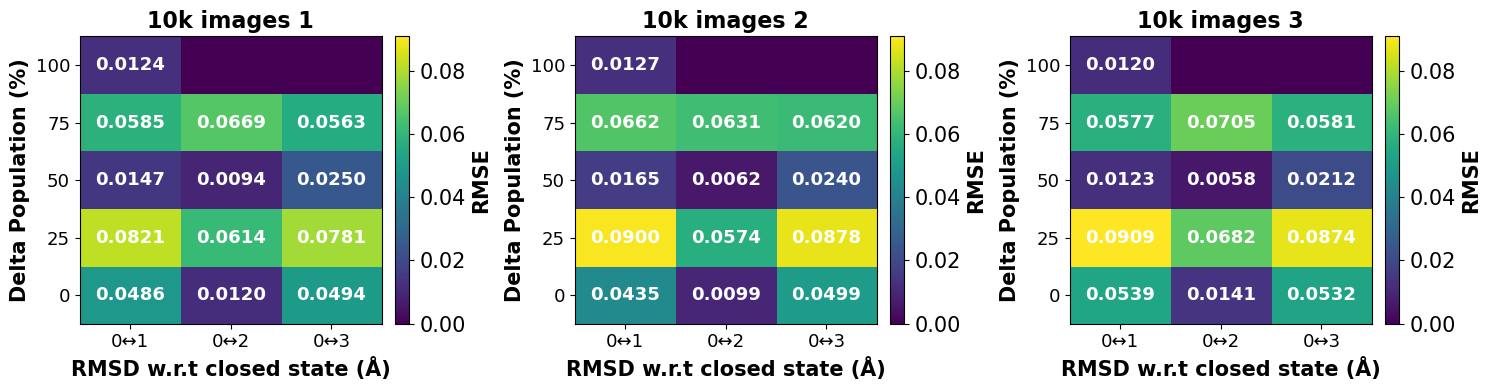

In [8]:
n = len(heatmaps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))  # 1 row, n columns

# If only one subplot, make it a list for consistency
if n == 1:
    axes = [axes]

for i in range(n):
    plt.sca(axes[i])  # Set the current axis
    plot_heatmap(heatmaps[i], x_levels, y_levels, title=title_labels[i],rmse_min=global_rmse_min, rmse_max=global_rmse_max)
#plt.savefig('heatmap.pdf')
plt.show()


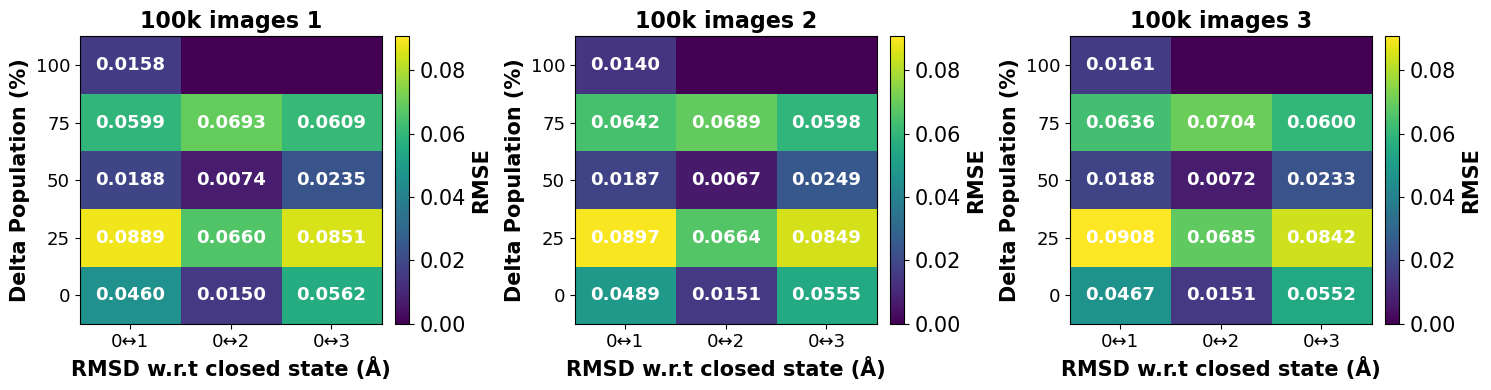

In [9]:
heatmaps, x_levels, y_levels = compute_rmse_heatmaps(
    rmse_list=[rmse_values_100k_1,rmse_values_100k_2, rmse_values_100k_3],
    pop_fraction_list=[pop_fractions_100k_1,pop_fractions_100k_2, pop_fractions_100k_3],
    rmsds_to_closed=rmsds_to_closed,
    models=models,
    population_steps=5
)
title_labels = ["100k images 1","100k images 2","100k images 3"]
global_rmse_min = np.nanmin([np.nanmin(hm) for hm in heatmaps])
global_rmse_max = np.nanmax([np.nanmax(hm) for hm in heatmaps])

n = len(heatmaps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))  # 1 row, n columns

# If only one subplot, make it a list for consistency
if n == 1:
    axes = [axes]

for i in range(n):
    plt.sca(axes[i])  # Set the current axis
    plot_heatmap(heatmaps[i], x_levels, y_levels, title=title_labels[i],rmse_min=global_rmse_min, rmse_max=global_rmse_max)
#plt.savefig('heatmap.pdf')
plt.show()



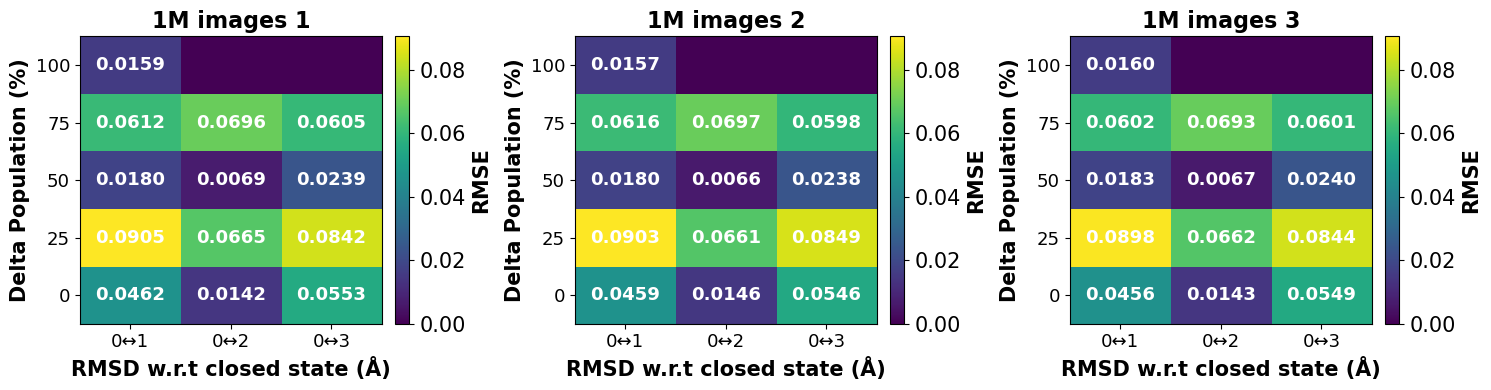

In [10]:
heatmaps, x_levels, y_levels = compute_rmse_heatmaps(
    rmse_list=[rmse_values_1M_1,rmse_values_1M_2, rmse_values_1M_3],
    pop_fraction_list=[pop_fractions_1M_1,pop_fractions_1M_2, pop_fractions_1M_3],
    rmsds_to_closed=rmsds_to_closed,
    models=models,
    population_steps=5
)
title_labels = ["1M images 1","1M images 2","1M images 3"]
global_rmse_min = np.nanmin([np.nanmin(hm) for hm in heatmaps])
global_rmse_max = np.nanmax([np.nanmax(hm) for hm in heatmaps])

n = len(heatmaps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))  # 1 row, n columns

# If only one subplot, make it a list for consistency
if n == 1:
    axes = [axes]

for i in range(n):
    plt.sca(axes[i])  # Set the current axis
    plot_heatmap(heatmaps[i], x_levels, y_levels, title=title_labels[i],rmse_min=global_rmse_min, rmse_max=global_rmse_max)
#plt.savefig('heatmap.pdf')
plt.show()



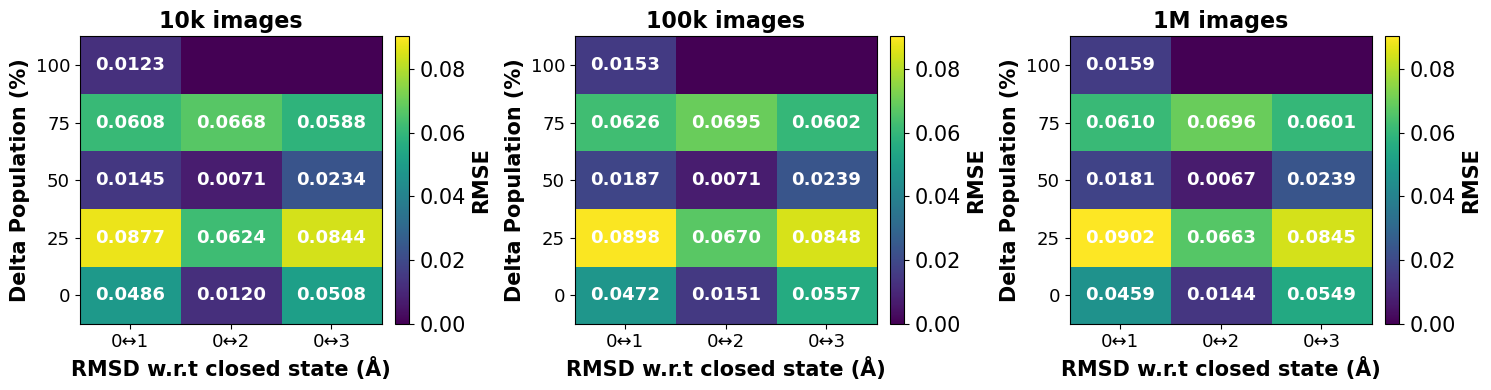

In [11]:
heatmaps, x_levels, y_levels = compute_rmse_heatmaps(
    rmse_list=[rmse_values_10k, rmse_values_100k, rmse_values_1M],
    pop_fraction_list=[pop_fractions_10k_1, pop_fractions_100k_1, pop_fractions_1M_1],
    rmsds_to_closed=rmsds_to_closed,
    models=models,
    population_steps=5
)
title_labels = ["10k images","100k images","1M images"]
global_rmse_min = np.nanmin([np.nanmin(hm) for hm in heatmaps])
global_rmse_max = np.nanmax([np.nanmax(hm) for hm in heatmaps])

n = len(heatmaps)
fig, axes = plt.subplots(1, n, figsize=(5*n, 4))  # 1 row, n columns

# If only one subplot, make it a list for consistency
if n == 1:
    axes = [axes]

for i in range(n):
    plt.sca(axes[i])  # Set the current axis
    plot_heatmap(heatmaps[i], x_levels, y_levels, title=title_labels[i],rmse_min=global_rmse_min, rmse_max=global_rmse_max)
#plt.savefig('heatmap.pdf')
plt.show()



In [12]:
np.save('embed_dim_16_heatmap',heatmaps)
np.save('embed_dim_16_x_levels',x_levels)
np.save('embed_dim_16_y_levels',y_levels)

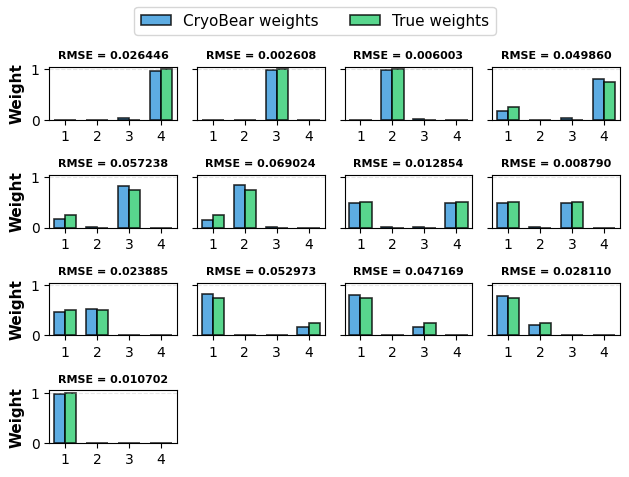

In [8]:
n = len(w_opt_10k)   # 13
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    #figsize=(5 * cols, 4 * rows),
    sharey=True
)

axes = axes.flatten()

for i in range(n):
    plot_weights_comparison(
        w_opt_10k[i],
        w_actual_10k[i],
        axes[i]
    )

# Remove empty subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Optional: one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11
)
for i, ax in enumerate(axes[:n]):
    if i % cols != 0:
        ax.set_ylabel("")
    ax.set_xlabel("")



plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('weights_10k.pdf')
plt.show()


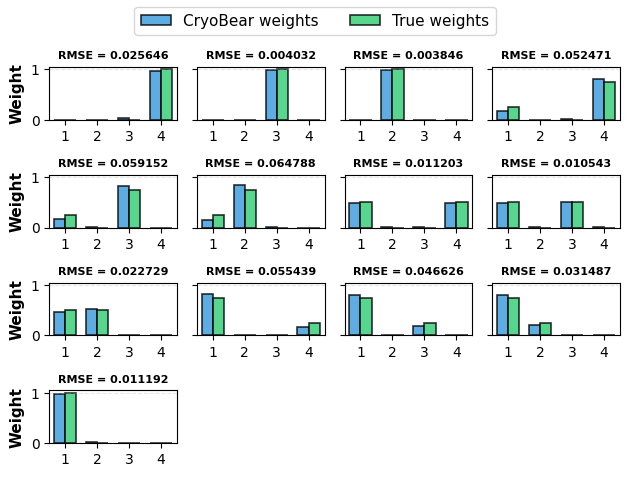

In [9]:
n = len(w_opt_100k)   # 13
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    #figsize=(5 * cols, 4 * rows),
    sharey=True
)

axes = axes.flatten()

for i in range(n):
    plot_weights_comparison(
        w_opt_100k[i],
        w_actual_100k[i],
        axes[i]
    )

# Remove empty subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Optional: one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11
)
for i, ax in enumerate(axes[:n]):
    if i % cols != 0:
        ax.set_ylabel("")
    ax.set_xlabel("")



plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('weights_100k.pdf')

plt.show()


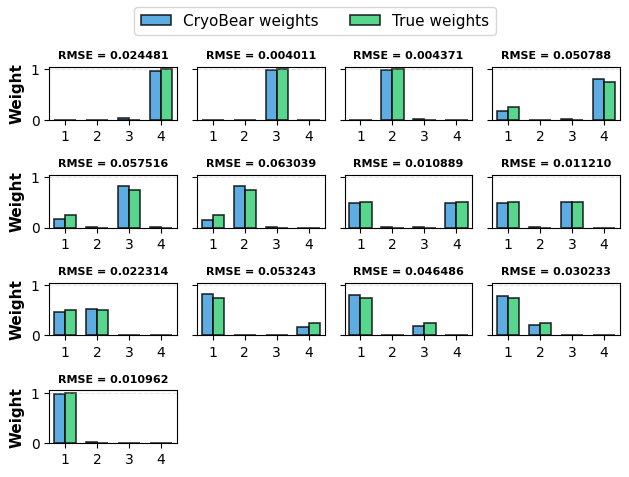

In [10]:
n = len(w_opt_1M)   # 13
cols = 4
rows = math.ceil(n / cols)

fig, axes = plt.subplots(
    rows,
    cols,
    #figsize=(5 * cols, 4 * rows),
    sharey=True
)

axes = axes.flatten()

for i in range(n):
    plot_weights_comparison(
        w_opt_1M[i],
        w_actual_1M[i],
        axes[i]
    )

# Remove empty subplots
for j in range(n, len(axes)):
    fig.delaxes(axes[j])

# Optional: one shared legend
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="upper center",
    ncol=2,
    fontsize=11
)
for i, ax in enumerate(axes[:n]):
    if i % cols != 0:
        ax.set_ylabel("")
    ax.set_xlabel("")



plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.savefig('weights_1M.pdf')
plt.show()


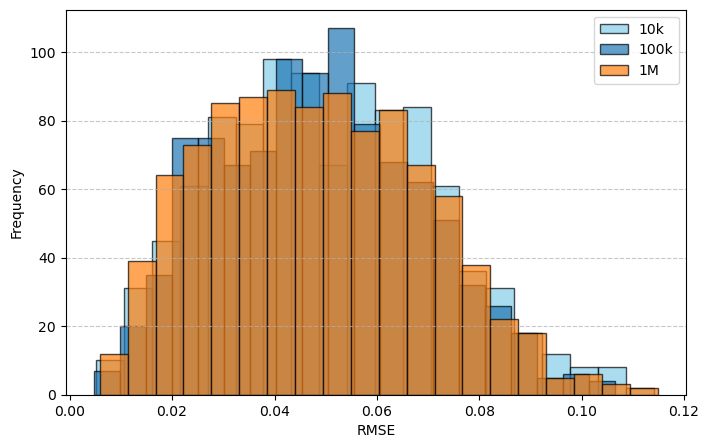

In [6]:
plt.figure(figsize=(8, 5))
plt.hist(rmse_random_10k, bins=20, color='skyblue', edgecolor='black', alpha=0.7, label = '10k')
plt.hist(rmse_random_100k, bins=20,edgecolor='black', alpha=0.7, label = '100k')
plt.hist(rmse_random_1M, bins=20,edgecolor='black', alpha=0.7, label = '1M')
plt.xlabel('RMSE')
plt.ylabel('Frequency')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()
plt.show()


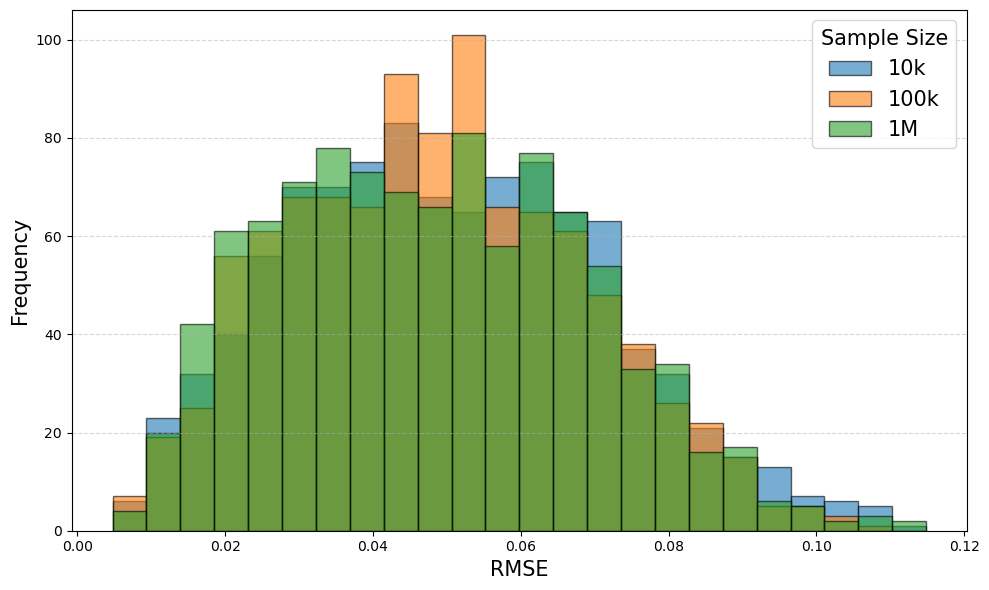

In [11]:


# Combine all RMSE data to get consistent bins
all_values = np.concatenate([rmse_random_10k, rmse_random_100k, rmse_random_1M])
bins = np.linspace(all_values.min(), all_values.max(), 25)

plt.figure(figsize=(10, 6))

# Modern colors with transparency
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Blue, Orange, Green

# Plot histograms
plt.hist(rmse_random_10k, bins=bins, alpha=0.6, label='10k', color=colors[0], edgecolor='black')
plt.hist(rmse_random_100k, bins=bins, alpha=0.6, label='100k', color=colors[1], edgecolor='black')
plt.hist(rmse_random_1M, bins=bins, alpha=0.6, label='1M', color=colors[2], edgecolor='black')

# Labels and title
plt.xlabel('RMSE', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
#plt.title('RMSE Distribution for Different Sample Sizes', fontsize=15, pad=15)

# Grid and legend
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend(title='Sample Size', fontsize=15, title_fontsize=15)

# Tight layout
plt.tight_layout()
plt.savefig('rmse_distribution_spatial_cryo.pdf')
plt.show()


/tmp/ipykernel_3490509/2963918829.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


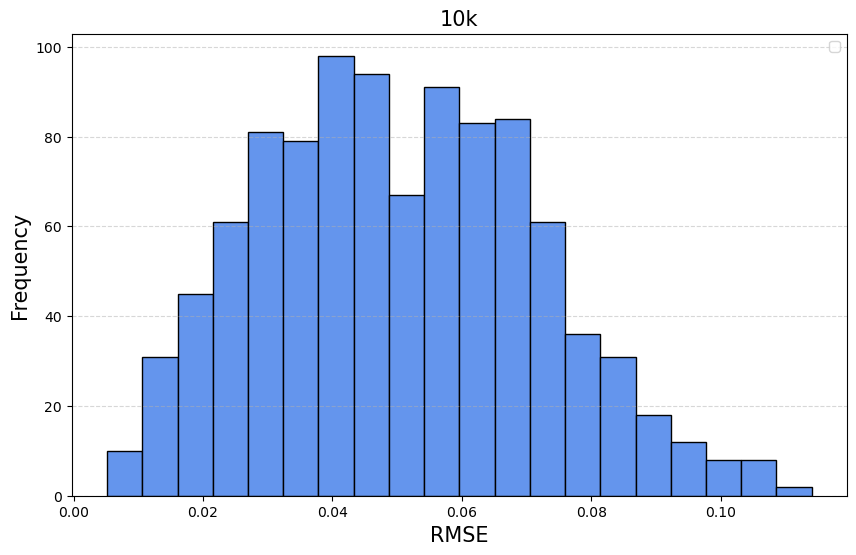

/tmp/ipykernel_3490509/2963918829.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


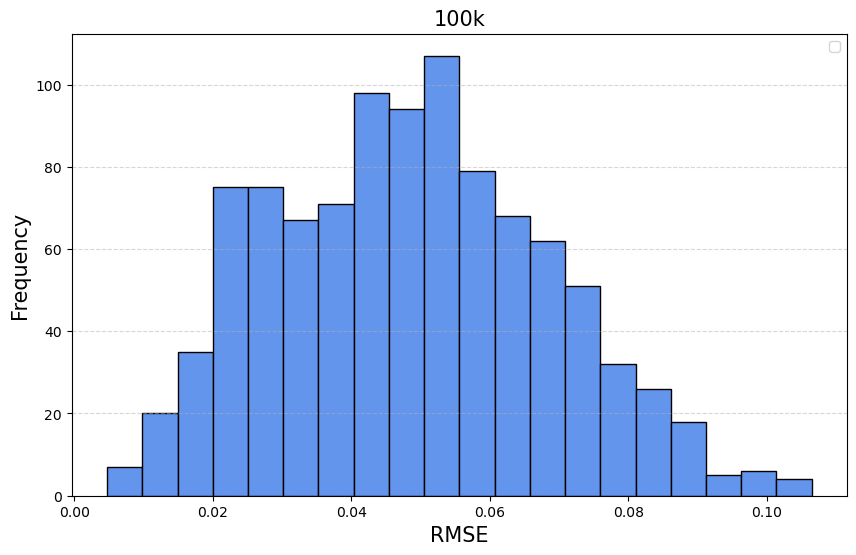

/tmp/ipykernel_3490509/2963918829.py:28: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


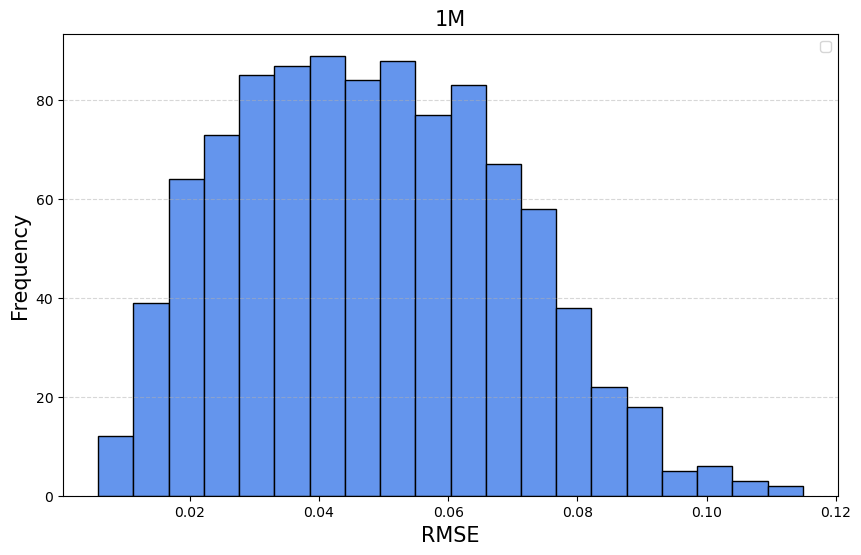

In [13]:

plt.figure(figsize=(10, 6))
plt.hist(rmse_random_10k, bins=20, color='cornflowerblue', edgecolor='black')
plt.xlabel('RMSE', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.title('10k', fontsize=15)
plt.savefig('rmse_distribution_spatial_cryo_10k.pdf')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(rmse_random_100k, bins=20, color='cornflowerblue', edgecolor='black')
plt.xlabel('RMSE', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.title('100k', fontsize=15)
plt.savefig('rmse_distribution_spatial_cryo_100k.pdf')
plt.show()


plt.figure(figsize=(10, 6))
plt.hist(rmse_random_1M, bins=20, color='cornflowerblue', edgecolor='black')
plt.xlabel('RMSE', fontsize=15)
plt.ylabel('Frequency', fontsize=15)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.legend()
plt.title('1M', fontsize=15)
plt.savefig('rmse_distribution_spatial_cryo_1M.pdf')
plt.show()

